# Predictive Paradox — Diagnostic Exploratory Data Analysis

**Objective:** Investigate the raw data to identify anomalies, structural issues, and undocumented errors before applying any transformations.

**Investigations:**
1. **Distribution Analysis:** Identify extreme outliers to justify the use of robust statistical filtering.

2. **Time Series Plotting:** Visually confirm the presence of the severe anomalous spikes warned about in the project brief.

3. **Missing Value Heatmap:** Map the density of missing data to dictate our imputation strategy.

4. **Temporal Alignment Check:** Compare the start and end dates of all three datasets to plan the final merging strategy.

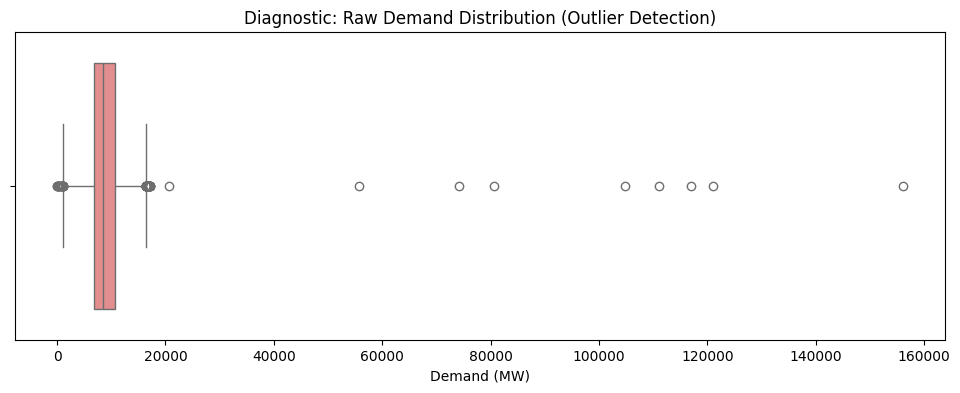

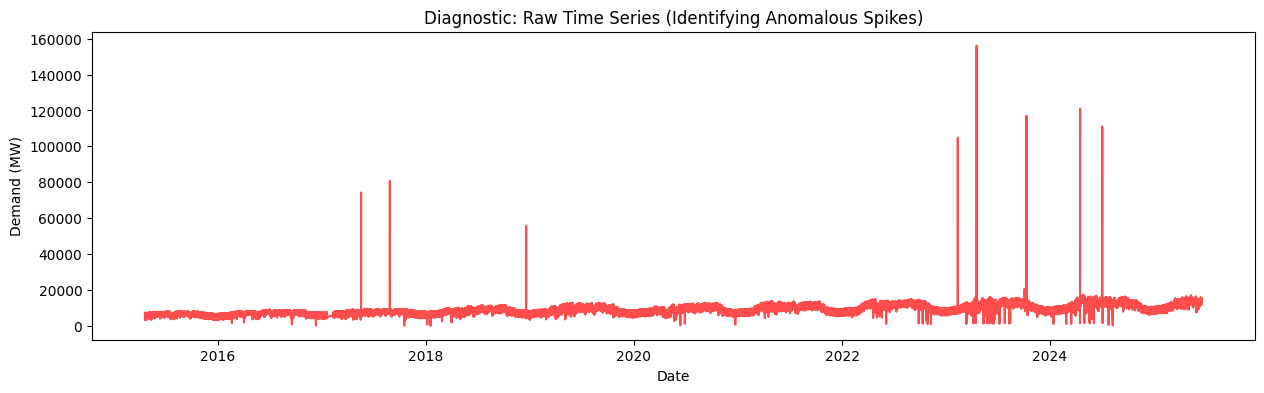

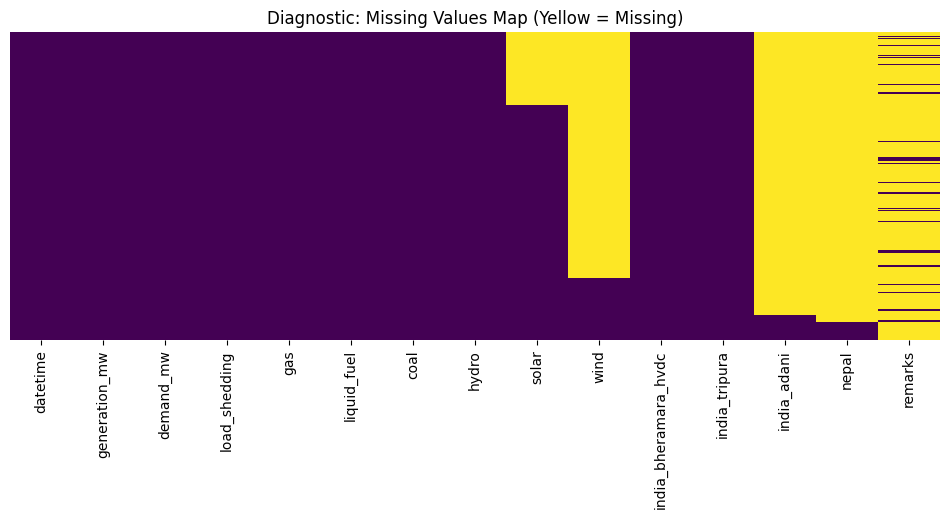

--- Temporal Alignment Check ---
PGCB Data:    2015-04-19 00:00:00 to 2025-06-17 12:00:00
Weather Data: 2014-01-01 00:00:00 to 2026-03-29 23:00:00


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_excel('../data/raw/PGCB_date_power_demand.xlsx', parse_dates=['datetime'], engine='openpyxl')
df_weather = pd.read_excel('../data/raw/weather_data.xlsx', skiprows=3, parse_dates=['time'], engine='openpyxl').rename(columns={'time': 'datetime'})

plt.figure(figsize=(12, 4))
sns.boxplot(x=df['demand_mw'], color='lightcoral')
plt.title('Diagnostic: Raw Demand Distribution (Outlier Detection)')
plt.xlabel('Demand (MW)')
plt.show()

plt.figure(figsize=(15, 4))
plt.plot(df['datetime'], df['demand_mw'], color='red', alpha=0.7)
plt.title('Diagnostic: Raw Time Series (Identifying Anomalous Spikes)')
plt.ylabel('Demand (MW)')
plt.xlabel('Date')
plt.show()

plt.figure(figsize=(12, 4))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Diagnostic: Missing Values Map (Yellow = Missing)')
plt.show()

print("--- Temporal Alignment Check ---")
print(f"PGCB Data:    {df['datetime'].min()} to {df['datetime'].max()}")
print(f"Weather Data: {df_weather['datetime'].min()} to {df_weather['datetime'].max()}")

---
## Data Cleaning

### Steps covered:
1. **Merge half-hourly (`:30`) timestamps** into their corresponding hourly (`:00`) timestamp using a weighted average
2. **Fill missing hourly timestamps** by using linear interpolation

In [2]:
import numpy as np

df = pd.read_excel('../data/raw/PGCB_date_power_demand.xlsx')
df = df.sort_values('datetime').reset_index(drop=True)

numeric_cols = df.select_dtypes(include='number').columns.tolist()

print(f'Raw shape                  : {df.shape}')
print(f'Date range                 : {df["datetime"].min()}  to  {df["datetime"].max()}')
print(f'Hourly (:00) rows          : {(df["datetime"].dt.minute == 0).sum()}')
print(f'Half-hourly (:30) rows     : {(df["datetime"].dt.minute == 30).sum()}')
print(f'Duplicate :00 timestamps   : {df[df["datetime"].dt.minute==0].duplicated(subset="datetime").sum()}')
print(f'Duplicate :30 timestamps   : {df[df["datetime"].dt.minute==30].duplicated(subset="datetime").sum()}')
df.head()

Raw shape                  : (92650, 15)
Date range                 : 2015-04-19 00:00:00  to  2025-06-17 12:00:00
Hourly (:00) rows          : 88469
Half-hourly (:30) rows     : 4181
Duplicate :00 timestamps   : 423
Duplicate :30 timestamps   : 9


,datetime,generation_mw,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,solar,wind,india_bheramara_hvdc,india_tripura,india_adani,nepal,remarks
0,2015-04-19 00:00:00,4821.0,4821,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
1,2015-04-19 01:00:00,3612.0,3612,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
2,2015-04-19 02:00:00,3727.0,3727,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
3,2015-04-19 03:00:00,3632.0,3632,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN
4,2015-04-19 04:00:00,3641.0,3641,0,0,0,0,0,NaN,NaN,0,0,NaN,NaN,NaN


---
## Pre-step — Resolve duplicate timestamps within each minute bucket

Some `:00` (and potentially `:30`) timestamps appear more than once.  
We collapse duplicates by **averaging all numeric columns** and keeping the first non-null remark.

In [3]:
def collapse_duplicates(frame):
    agg_dict = {col: 'mean' for col in numeric_cols if col in frame.columns}
    agg_dict['remarks'] = lambda x: next((v for v in x if pd.notna(v) and str(v) != 'nan'), np.nan)
    return frame.groupby('datetime', sort=True).agg(agg_dict).reset_index()

df_hour = df[df['datetime'].dt.minute == 0].copy()
df_half = df[df['datetime'].dt.minute == 30].copy()

print(f':00 rows before dedup : {len(df_hour)}')
print(f':30 rows before dedup : {len(df_half)}')

df_hour = collapse_duplicates(df_hour)
df_half = collapse_duplicates(df_half)

print(f':00 rows after dedup  : {len(df_hour)}')
print(f':30 rows after dedup  : {len(df_half)}')

:00 rows before dedup : 88469
:30 rows before dedup : 4181
:00 rows after dedup  : 88046
:30 rows after dedup  : 4172


---
## Step 1 — Merge `:30` timestamps into their matching `:00` timestamp

**Logic:**
- For each `:30` row, find the `:00` row in the same hour (e.g. 17:30 -> 17:00).
- For all **numeric** columns take a **weighted average**.
- For **remarks** keep whichever side has a non-null value, preferring `:00`.
- The 4 edge-cases where a `:30` has no matching `:00` are simply **re-labelled as `:00`**.

In [4]:
# Weights (must sum to 1)
W_HOUR = 0.6
W_HALF = 0.4

df_half = df_half.copy()
df_hour = df_hour.copy()
df_half['_key'] = df_half['datetime'].dt.floor('h')
df_hour['_key'] = df_hour['datetime']

# Case A: :30 paired with existing :00
merged = df_hour.merge(df_half, on='_key', suffixes=('_h', '_30'), how='inner')

blended = pd.DataFrame({'datetime': merged['_key']})
for col in numeric_cols:
    h, t = col + '_h', col + '_30'
    blended[col] = np.where(
        merged[h].isna(), merged[t],
        np.where(merged[t].isna(), merged[h],
                 W_HOUR * merged[h] + W_HALF * merged[t])
    )

rh, rt = 'remarks_h', 'remarks_30'
blended['remarks'] = np.where(
    merged[rh].notna() & (merged[rh].astype(str) != 'nan'),
    merged[rh], merged[rt]
)

print(f'Case A (paired :30 merged into :00)    : {len(blended)} rows')

# Case B: orphan :30 with no matching :00 -> re-label as :00
orphans = df_half[~df_half['_key'].isin(df_hour['_key'])].copy()
orphans['datetime'] = orphans['_key']
orphans = orphans.drop(columns='_key')
print(f'Case B (orphan :30 re-labelled as :00) : {len(orphans)} rows')

# Unpaired :00 rows (no :30 partner) - keep as-is
paired_keys = set(merged['_key'])
df_hour_clean = df_hour[~df_hour['_key'].isin(paired_keys)].drop(columns='_key')
print(f'Unpaired :00 rows kept unchanged       : {len(df_hour_clean)}')

df_step1 = (
    pd.concat([df_hour_clean, blended, orphans], ignore_index=True)
    .sort_values('datetime')
    .reset_index(drop=True)
)

assert (df_step1['datetime'].dt.minute == 30).sum() == 0, 'Still has :30 rows!'
assert not df_step1['datetime'].duplicated().any(), 'Duplicate timestamps remain!'

print(f'\nShape after Step 1 : {df_step1.shape}')
print(f'Net rows removed   : {len(df) - len(df_step1)}')

Case A (paired :30 merged into :00)    : 4168 rows
Case B (orphan :30 re-labelled as :00) : 4 rows
Unpaired :00 rows kept unchanged       : 83878

Shape after Step 1 : (88050, 15)
Net rows removed   : 4600


### Quick check — compare original vs blended values

In [5]:
sample_keys = list(merged['_key'].iloc[:5])
orig = df[df['datetime'].dt.floor('h').isin(sample_keys)][['datetime','demand_mw','generation_mw','remarks']]
blnd = blended[blended['datetime'].isin(sample_keys)][['datetime','demand_mw','generation_mw','remarks']]

print('--- Original :00 and :30 rows ---')
print(orig.to_string(index=False))
print('\n--- Blended (weighted average) ---')
print(blnd.to_string(index=False))

--- Original :00 and :30 rows ---
           datetime  demand_mw  generation_mw      remarks
2015-04-19 17:00:00       5725         5725.0          NaN
2015-04-19 17:30:00       6299         6299.0          NaN
2015-04-19 18:00:00       6874         6874.0          NaN
2015-04-19 18:30:00       6933         6933.0 Evening_Peak
2015-04-21 17:00:00       6098         6098.0          NaN
2015-04-21 17:30:00       6698         6698.0          NaN
2015-04-21 18:00:00       7390         7390.0          NaN
2015-04-21 18:30:00       7409         7409.0          NaN
2015-04-22 17:00:00       5731         5731.0          NaN
2015-04-22 17:30:00       6195         6195.0          NaN

--- Blended (weighted average) ---
           datetime  demand_mw  generation_mw      remarks
2015-04-19 17:00:00     5954.6         5954.6          NaN
2015-04-19 18:00:00     6897.6         6897.6 Evening_Peak
2015-04-21 17:00:00     6338.0         6338.0          NaN
2015-04-21 18:00:00     7397.6         7397.6

---
## Step 2 — Fill missing hourly timestamps

**Logic:**
- Build a complete hourly index from the first to the last timestamp.
- Reindex against it so absent hours appear as NaN rows.
- Apply **linear interpolation** on numeric columns: fills each missing hour as the straight-line
  average between its two nearest known neighbours (exactly 'combine with the previous and next value').
- `remarks` is replaced with ***Normal*** for all missing values.

In [ ]:
full_index = pd.date_range(
    start=df_step1['datetime'].min(),  # Building a continuous hourly index from start to finish so we don't accidentally skip any missing hours
    end=df_step1['datetime'].max(),
    freq='h'
)

missing_ts = full_index.difference(df_step1['datetime'])
print(f'Total expected hourly timestamps : {len(full_index):,}')
print(f'Present after Step 1             : {len(df_step1):,}')
print(f'Missing timestamps to fill       : {len(missing_ts):,}')
if len(missing_ts):
    print('\nFirst 10 missing timestamps:')
    print(missing_ts[:10].tolist())

Total expected hourly timestamps : 89,101
Present after Step 1             : 88,050
Missing timestamps to fill       : 1,051

First 10 missing timestamps:
[Timestamp('2015-04-19 23:00:00'), Timestamp('2015-04-20 01:00:00'), Timestamp('2015-04-20 02:00:00'), Timestamp('2015-04-20 03:00:00'), Timestamp('2015-04-20 04:00:00'), Timestamp('2015-04-20 05:00:00'), Timestamp('2015-04-20 06:00:00'), Timestamp('2015-04-20 16:00:00'), Timestamp('2015-04-20 17:00:00'), Timestamp('2015-04-20 18:00:00')]


In [ ]:
df_reindexed = (
    df_step1
    .set_index('datetime')
    .reindex(full_index)
    .rename_axis('datetime')
    .reset_index()
)

for col in numeric_cols:
    if col in df_reindexed.columns:
        df_reindexed[col] = df_reindexed[col].interpolate(method='linear', limit_direction='forward')
# limit_direction='forward' is super important here so we don't accidentally leak future data backwards

df_reindexed['remarks'] = df_reindexed['remarks'].fillna('Normal')

nan_remaining = df_reindexed[['demand_mw', 'generation_mw']].isna().sum()
print('NaNs remaining in key columns:')
print(nan_remaining)

df_step2 = df_reindexed.copy()
print(f'\nFinal shape after Step 2 : {df_step2.shape}')

NaNs remaining in key columns:
demand_mw        0
generation_mw    0
dtype: int64

Final shape after Step 2 : (89101, 15)


### Visualise a gap-fill example

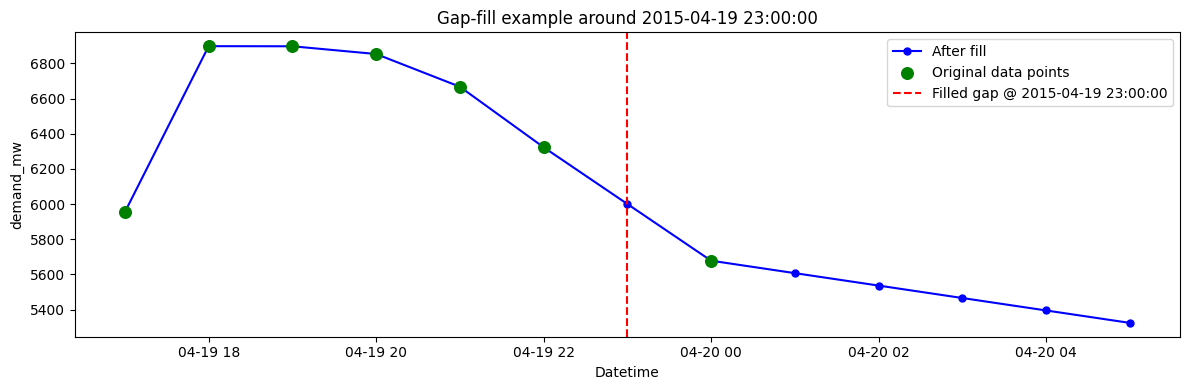

In [8]:
if len(missing_ts) > 0:
    gap_ts = missing_ts[0]
    window = pd.date_range(gap_ts - pd.Timedelta(hours=6),
                           gap_ts + pd.Timedelta(hours=6), freq='h')

    before_fill = df_step1[df_step1['datetime'].isin(window)]
    after_fill  = df_step2[df_step2['datetime'].isin(window)]

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(after_fill['datetime'], after_fill['demand_mw'],
            'b-o', ms=5, label='After fill', linewidth=1.5)
    ax.scatter(before_fill['datetime'], before_fill['demand_mw'],
               color='green', zorder=5, s=70, label='Original data points')
    ax.axvline(gap_ts, color='red', linestyle='--', label=f'Filled gap @ {gap_ts}')
    ax.set_title(f'Gap-fill example around {gap_ts}')
    ax.set_xlabel('Datetime')
    ax.set_ylabel('demand_mw')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No missing timestamps — nothing to plot.')

---
## Summary

In [9]:
gaps_closed = df_step2['datetime'].diff().dropna().eq(pd.Timedelta(hours=1)).all()
dup_00 = df[df['datetime'].dt.minute == 0].duplicated(subset='datetime').sum()

print('=' * 47)
print('          CLEANING SUMMARY')
print('=' * 47)
print(f'  Raw rows                        : {len(df):>8,}')
print(f'  Duplicate :00 rows collapsed    : {dup_00:>8,}')
print(f'  Half-hourly (:30) rows merged   : {len(df_half):>8,}')
print(f'  After Step 1 (dedup + merge)    : {len(df_step1):>8,}')
print(f'  Missing hours filled (Step 2)   : {len(missing_ts):>8,}')
print(f'  Final rows                      : {len(df_step2):>8,}')
print(f'  Perfectly hourly index          : {gaps_closed}')
print('=' * 47)


          CLEANING SUMMARY
  Raw rows                        :   92,650
  Duplicate :00 rows collapsed    :      423
  Half-hourly (:30) rows merged   :    4,172
  After Step 1 (dedup + merge)    :   88,050
  Missing hours filled (Step 2)   :    1,051
  Final rows                      :   89,101
  Perfectly hourly index          : True


---
## Step 3: Outlier Detection (S-ESD Approach)

**Methodology:**
1. **Decompose:** Use `statsmodels` to strip away the normal 24-hour seasonality and trend.

2. **Thresholding:** Calculate the Median Absolute Deviation (MAD) on the remaining residual noise. Flag any point with a modified Z-score > 3.5 as a true anomaly.

3. **Leakage-Free Imputation:** Replace flagged anomalies using a strictly backward-looking 3-hour rolling median (`.shift(1)`) to prevent future data leakage.

--- Running Seasonal Decomposition Anomaly Detection ---
Detected 409 anomalies in the residual noise.
Outliers removed and smoothly imputed using historical data.
Final shape after Step 3: (89101, 15)


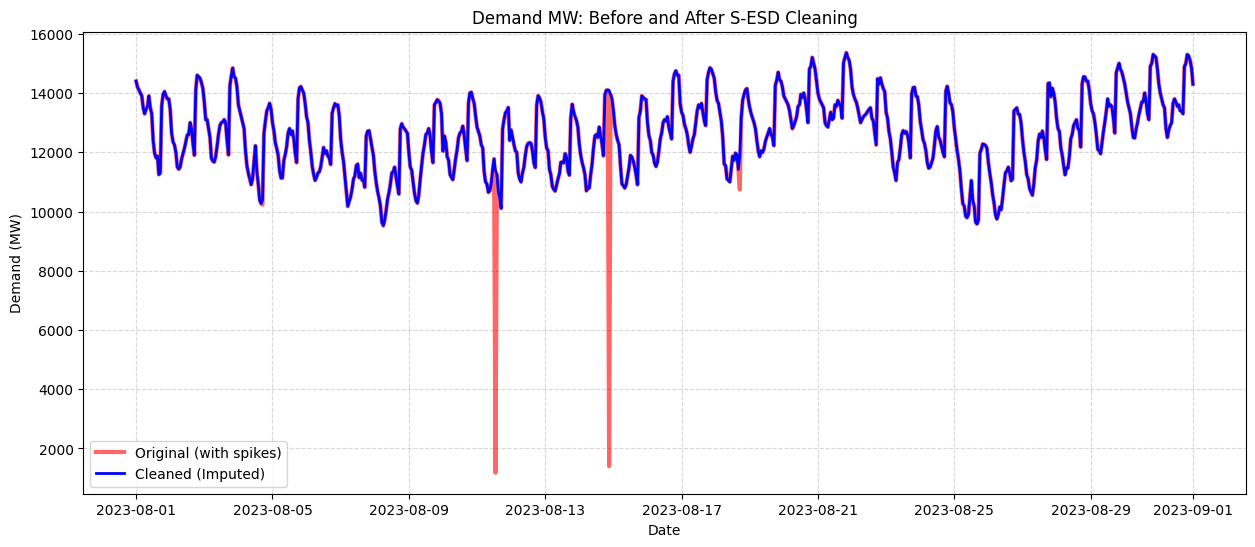

In [ ]:
import os
from statsmodels.tsa.seasonal import seasonal_decompose

print("--- Running Seasonal Decomposition Anomaly Detection ---")

ts_data = df_step2['demand_mw']

decomposition = seasonal_decompose(ts_data, model='additive', period=24)
residuals = decomposition.resid

clean_resid = residuals.dropna()
median_resid = np.median(clean_resid)
mad = np.median(np.abs(clean_resid - median_resid))

mod_z_scores = 0.6745 * (residuals - median_resid) / mad
threshold = 3.5
outliers_condition = np.abs(mod_z_scores) > threshold

num_outliers = outliers_condition.sum()
print(f"Detected {num_outliers} anomalies in the residual noise.")

df_step3 = df_step2.copy()
df_step3.loc[outliers_condition, 'demand_mw'] = np.nan

# The .shift(1) is crucial here—it forces the rolling window to only look at the past, preventing data leakage
past_rolling_median = df_step3['demand_mw'].rolling(window=3, min_periods=1).median().shift(1)
# Replacing the flagged anomalies using a 3-hour rolling median

df_step3['demand_mw'] = df_step3['demand_mw'].fillna(past_rolling_median)
df_step3['demand_mw'] = df_step3['demand_mw'].ffill()

print("Outliers removed and smoothly imputed using historical data.")
print(f"Final shape after Step 3: {df_step3.shape}")

start_date = '2023-08-01'
end_date = '2023-09-01'
df_step2_plot = df_step2[(df_step2['datetime'] >= start_date) & (df_step2['datetime'] <= end_date)]
df_step3_plot = df_step3[(df_step3['datetime'] >= start_date) & (df_step3['datetime'] <= end_date)]

if num_outliers > 0:
    plt.figure(figsize=(15, 6))
    plt.plot(df_step2_plot['datetime'], df_step2_plot['demand_mw'], label='Original (with spikes)', color='red', alpha=0.6, linewidth=3)
    plt.plot(df_step3_plot['datetime'], df_step3_plot['demand_mw'], label='Cleaned (Imputed)', color='blue', linewidth=2)
    plt.title('Demand MW: Before and After S-ESD Cleaning')
    plt.xlabel('Date')
    plt.ylabel('Demand (MW)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

os.makedirs('../data/processed', exist_ok=True)
df_step3.to_csv('../data/processed/PGCB_fully_cleaned.csv', index=True)

---
## Step 4: Weather Data Preprocessing

**Methodology:**
1. **Format:** Skip metadata rows to align column headers.

2. **Prune:** Drop redundant features (`dew_point`, `soil_temperature`) to prevent multicollinearity.

3. **Encode:** Convert `wind_direction` from raw degrees into cyclical features (`sine` and `cosine`) to preserve its continuous circular nature for the machine learning model.

In [11]:
df_weather = pd.read_excel('../data/raw/weather_data.xlsx', skiprows=3)
rename_map = {
    'time': 'datetime',
    'temperature_2m (°C)': 'temp_c',
    'relative_humidity_2m (%)': 'humidity_pct',
    'precipitation (mm)': 'precip_mm',
    'wind_direction_10m (°)': 'wind_dir_deg',
    'cloud_cover (%)': 'cloud_cover_pct',
    'sunshine_duration (s)': 'sunshine_dur_s'
}
df_weather = df_weather.rename(columns=rename_map)

cols_to_drop = ['dew_point_2m (°C)', 'soil_temperature_0_to_7cm (°C)', 'apparent_temperature (°C)']
df_weather = df_weather.drop(columns=cols_to_drop)

wind_radians = np.deg2rad(df_weather['wind_dir_deg'])
df_weather['wind_dir_sin'] = np.sin(wind_radians)
df_weather['wind_dir_cos'] = np.cos(wind_radians)
df_weather = df_weather.drop(columns=['wind_dir_deg'])

df_weather['datetime'] = pd.to_datetime(df_weather['datetime'])

print(f"Weather Shape: {df_weather.shape}")
df_weather.to_csv('../data/processed/weather_data_cleaned.csv', index=True)
df_weather.head()

Weather Shape: (107304, 8)


,datetime,temp_c,humidity_pct,precip_mm,cloud_cover_pct,sunshine_dur_s,wind_dir_sin,wind_dir_cos
0,2014-01-01 00:00:00,13.9,89,0.0,0,0.0,-0.731354,0.681998
1,2014-01-01 01:00:00,13.6,91,0.0,0,0.0,-0.681998,0.731354
2,2014-01-01 02:00:00,13.3,91,0.0,0,0.0,-0.681998,0.731354
3,2014-01-01 03:00:00,13.0,92,0.0,0,0.0,-0.656059,0.754710
4,2014-01-01 04:00:00,12.7,93,0.0,0,0.0,-0.615661,0.788011


---
## Step 5: Economic Data Preprocessing

**Methodology:**
1. **Selection:** Extracts 5 stationary, orthogonal indicators (GDP Growth, Population, Industry %, Electricity Access, Urbanization) to ensure model stability.

2. **Temporal Alignment:** Maps annual data to the 2014–2025 timeline, extending 2024 values to 2025 to cover the PGCB grid dataset range.

3. **Reshaping:** Transform the wide annual matrix into a tidy feature-set.

In [ ]:
df_eco_raw = pd.read_csv('../data/raw/economic_full_1.csv')

target_indicators = [
    'GDP per capita growth (annual %)',
    'Population, total',
    'Industry (including construction), value added (% of GDP)',
    'Access to electricity (% of population)',
    'Urban population (% of total population)'
]

df_eco_filtered = df_eco_raw[df_eco_raw['Indicator Name'].isin(target_indicators)].copy()

years_to_keep = [str(year) for year in range(2014, 2025)]
columns_to_keep = ['Indicator Name'] + years_to_keep
df_eco_filtered = df_eco_filtered[columns_to_keep]

df_eco_melted = df_eco_filtered.melt(
    id_vars=['Indicator Name'],
    value_vars=years_to_keep,
    var_name='Year',
    value_name='Value'
)

df_economic = df_eco_melted.pivot(
    index='Year',
    columns='Indicator Name',
    values='Value'
).reset_index()

df_economic.columns.name = None
rename_eco_map = {
    'Year': 'year',
    'GDP per capita growth (annual %)': 'gdp_growth_pct',
    'Population, total': 'population',
    'Industry (including construction), value added (% of GDP)': 'industry_pct_gdp',
    'Access to electricity (% of population)': 'elec_access_pct',
    'Urban population (% of total population)': 'urban_pop_pct'
}
df_economic = df_economic.rename(columns=rename_eco_map)

df_economic['year'] = df_economic['year'].astype(int)
df_economic = df_economic.ffill()
# No 2025 economic data, just carry over the 2024 values to prevent NaNs in the merged test dataset
row_2025 = df_economic[df_economic['year'] == 2024].copy()
row_2025['year'] = 2025
df_economic = pd.concat([df_economic, row_2025], ignore_index=True)

print(f"Economic Data Ready: {df_economic.shape}")
df_economic.to_csv('../data/processed/economic_data_cleaned.csv', index=True)
df_economic

Economic Data Ready: (12, 6)


,year,elec_access_pct,gdp_growth_pct,industry_pct_gdp,population,urban_pop_pct
0,2014,62.4,5.099055,26.311047,157964929.0,29.194444
1,2015,74.0,5.604495,26.831395,159383179.0,29.539510
2,2016,75.9,6.161816,31.069151,160811932.0,29.875392
3,2017,88.0,5.687103,31.248292,162186147.0,30.201580
4,2018,86.9,6.441975,31.982814,163523103.0,30.517566
5,2019,92.2,6.972644,32.852549,164913055.0,30.822840
6,2020,96.2,2.586478,32.911565,166298024.0,31.116893
7,2021,99.0,6.070694,33.316094,167658854.0,31.399216
8,2022,99.4,6.008475,33.920080,169384897.0,31.673735
9,2023,99.5,4.490704,34.594272,171466990.0,32.157846


---
## Step 6: Merging the Dataset

**Methodology:**
1. **Hourly Alignment:** Perform an left join on the Grid and Weather datasets using the exact `datetime` index to explicitly map weather data without altering the target variable's temporal structure.

2. **Annual Mapping:** Extract the `year` from the aligned timeline to act as a joining key.
3. **Macro Integration:** Perform a left join to broadcast the annual macroeconomic indicators across every corresponding hour of the year.

In [13]:
df_merged_hourly = pd.merge(df_step3, df_weather, on='datetime', how='left')

df_merged_hourly['year'] = df_merged_hourly['datetime'].dt.year

df_master = pd.merge(df_merged_hourly, df_economic, on='year', how='left')
df_master = df_master.drop(columns=['solar', 'wind', 'india_adani', 'nepal', 'generation_mw'])

print(f"Master Dataset Shape: {df_master.shape}")
print("\nMissing values after merge (Should be 0):")
print(df_master.isna().sum().sum())

Master Dataset Shape: (89101, 23)

Missing values after merge (Should be 0):
0


---
## Analytical Exploratory Data Analysis

**Objective:** Analyze the cleaned, merged master dataset to uncover the mathematical relationships that will directly dictate our Feature Engineering architecture.

**Investigations:**
1. **Temporal Seasonality:** Analyze demand by hour and day of the week to justify the creation of cyclical encoding and specific lag features (24h, 168h).

2. **Weather Correlation:** Map the correlation matrix between demand and thermodynamic variables to validate their inclusion as exogenous features.

3. **Macro-Economic Growth:** Visualize the year-over-year baseline shift to justify the inclusion of annual economic indicators in a high-frequency grid model.

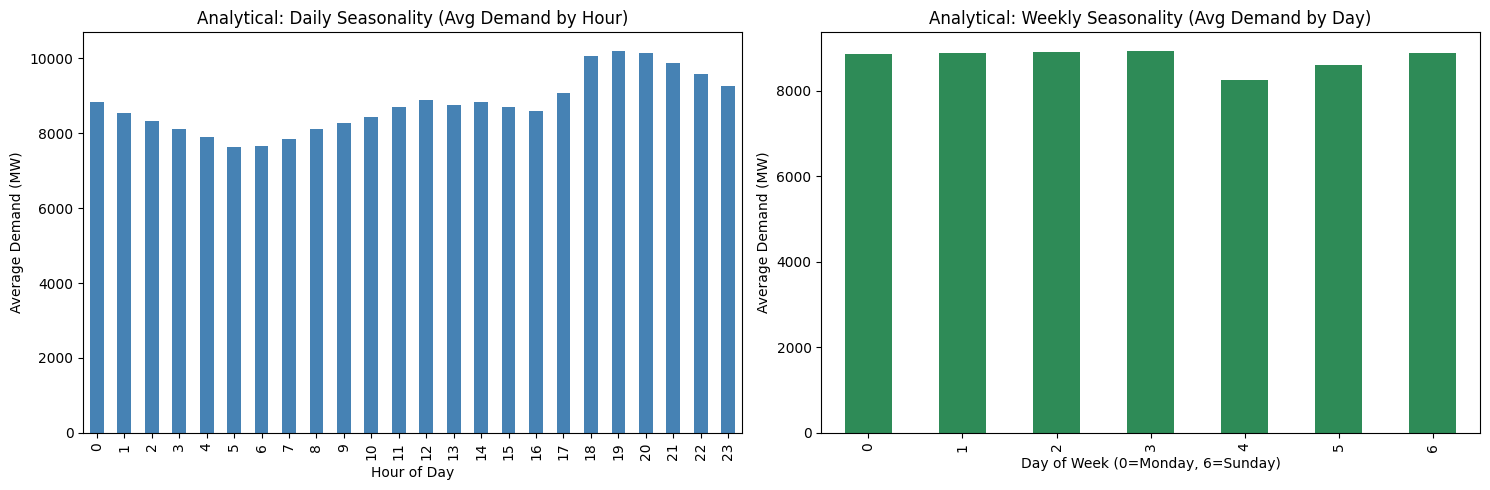

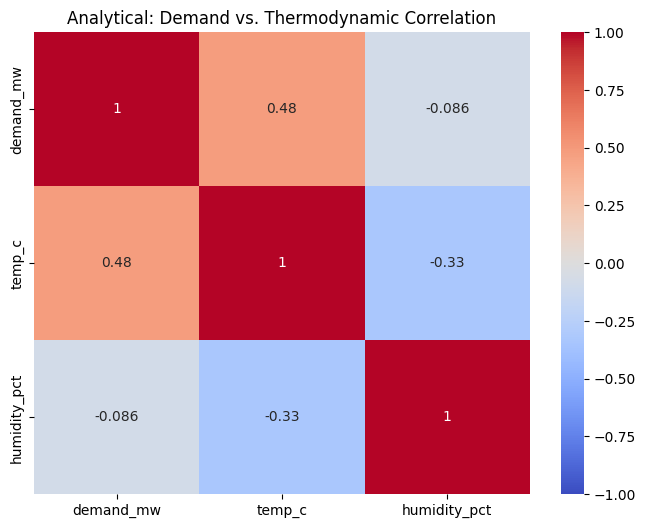

C:\Users\User\AppData\Local\Temp\ipykernel_33788\4077364862.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_master, x='year', y='demand_mw', palette='Blues')


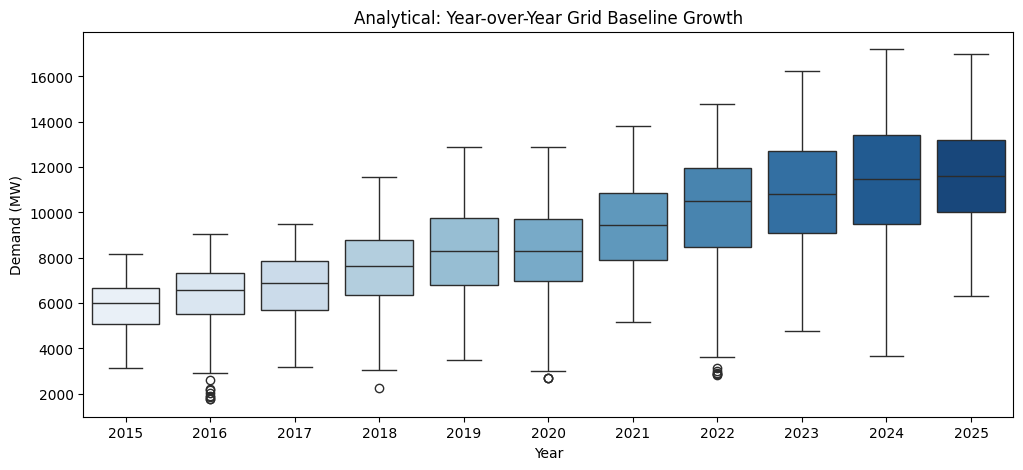

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df_master.groupby(df_master['datetime'].dt.hour)['demand_mw'].mean().plot(
    kind='bar', ax=axes[0], color='steelblue'
)
axes[0].set_title('Analytical: Daily Seasonality (Avg Demand by Hour)')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Average Demand (MW)')

df_master.groupby(df_master['datetime'].dt.dayofweek)['demand_mw'].mean().plot(
    kind='bar', ax=axes[1], color='seagreen'
)
axes[1].set_title('Analytical: Weekly Seasonality (Avg Demand by Day)')
axes[1].set_xlabel('Day of Week (0=Monday, 6=Sunday)')
axes[1].set_ylabel('Average Demand (MW)')

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
weather_cols = ['demand_mw', 'temp_c', 'humidity_pct']
sns.heatmap(df_master[weather_cols].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Analytical: Demand vs. Thermodynamic Correlation')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df_master, x='year', y='demand_mw', palette='Blues')
plt.title('Analytical: Year-over-Year Grid Baseline Growth')
plt.xlabel('Year')
plt.ylabel('Demand (MW)')
plt.show()

## Step 7: Global Feature Engineering

**Methodology:**
1. **Calendar/Time Structure:** Extract temporal features (hour, day, month, weekend) and apply cyclical encoding to preserve the continuous nature of time.

2. **Categorical Encoding:** One-hot encode textual event flags into binary formats.

3. **Historical Demand Features:** Generate standard offsets (1h, 2h, 24h, 168h) and rolling aggregates (6h/24h mean, 24h standard deviation) to provide short-term memory and variability metrics.

4. **Target Variable:** Shift demand backward by one hour to establish the supervised learning objective.

In [ ]:
df_master['hour'] = df_master['datetime'].dt.hour
df_master['day_of_week'] = df_master['datetime'].dt.dayofweek

#Cyclical encoding for month and hour to capture seasonality without introducing artificial discontinuities
df_master['month'] = df_master['datetime'].dt.month
df_master['month_sin'] = np.sin(2 * np.pi * df_master['month'] / 12)
df_master['month_cos'] = np.cos(2 * np.pi * df_master['month'] / 12)

df_master['is_weekend'] = df_master['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

df_master['hour_sin'] = np.sin(2 * np.pi * df_master['hour'] / 24)
df_master['hour_cos'] = np.cos(2 * np.pi * df_master['hour'] / 24)
df_master = df_master.drop(columns=['month', 'hour'])

if 'remarks' in df_master.columns:
    df_master = pd.get_dummies(df_master, columns=['remarks'], prefix='remarks', dtype=int)

# Lag features to capture temporal dependencies
df_master['lag_1h'] = df_master['demand_mw'].shift(1)
df_master['lag_2h'] = df_master['demand_mw'].shift(2)
df_master['lag_24h'] = df_master['demand_mw'].shift(24)
df_master['lag_168h'] = df_master['demand_mw'].shift(168)

# Rolling statistics to capture local trends and volatility
df_master['rolling_mean_6h'] = df_master['demand_mw'].rolling(window=6).mean()
df_master['rolling_mean_24h'] = df_master['demand_mw'].rolling(window=24).mean()
df_master['rolling_std_24h'] = df_master['demand_mw'].rolling(window=24).std()

# Shifting target variable to align with the next hour's demand
df_master['target_mw'] = df_master['demand_mw'].shift(-1)

df_master = df_master.dropna().reset_index(drop=True)

print(f"Feature Engineering Complete. Final Shape: {df_master.shape}")
df_master.head()

Feature Engineering Complete. Final Shape: (88932, 39)


,datetime,demand_mw,load_shedding,gas,liquid_fuel,coal,hydro,india_bheramara_hvdc,india_tripura,temp_c,...,remarks_Evening_Peak,remarks_Normal,lag_1h,lag_2h,lag_24h,lag_168h,rolling_mean_6h,rolling_mean_24h,rolling_std_24h,target_mw
0,2015-04-26 00:00:00,6198.36,0.0,4958.48,584.72,156.64,45.68,452.84,0.0,22.0,...,0,1,6190.52,6182.68,5197.0,4821.0,6193.566667,4833.658333,903.791159,6206.20
1,2015-04-26 01:00:00,6206.20,0.0,4958.60,592.40,156.80,45.60,452.80,0.0,21.8,...,0,1,6198.36,6190.52,4987.0,3612.0,6186.600000,4884.458333,946.060623,6214.04
2,2015-04-26 02:00:00,6214.04,0.0,4958.72,600.08,156.96,45.52,452.76,0.0,21.6,...,0,1,6206.20,6198.36,4703.0,3727.0,6194.440000,4947.418333,983.017346,6221.88
3,2015-04-26 03:00:00,6221.88,0.0,4958.84,607.76,157.12,45.44,452.72,0.0,21.4,...,0,1,6214.04,6206.20,4510.0,3632.0,6202.280000,5018.746667,1011.590301,6229.72
4,2015-04-26 04:00:00,6229.72,0.0,4958.96,615.44,157.28,45.36,452.68,0.0,21.5,...,0,1,6221.88,6214.04,4230.0,3641.0,6210.120000,5102.068333,1026.051077,6237.56


---
## Step 8: Dataset Partitioning and Scaling

**Methodology:**
1. **Chronological Split:** Isolate the training data (2014–2023) from the testing data (2024–2025) to maintain temporal integrity.

2. **Target Isolation:** Separate the target variable (`target_mw`) from the feature matrix.

3. **Feature Scaling:** Utilize `MinMaxScalar` from the `sklearn.preprocessing` module to scale all features into a strict `[0, 1]` range, ensuring large economic figures and smaller weather metrics are evaluated uniformly without distorting their underlying distributions.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

train_df = df_master[df_master['datetime'].dt.year <= 2023].copy()
test_df = df_master[df_master['datetime'].dt.year >= 2024].copy()

drop_cols = ['datetime', 'target_mw', 'year']

X_train = train_df.drop(columns=drop_cols)
y_train = train_df['target_mw']

X_test = test_df.drop(columns=drop_cols)
y_test = test_df['target_mw']

# Scaling features to 0-1 range to prevent massive numbers to dominate the model training
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print(f"Training features shape: {X_train.shape}")
print(f"Testing features shape: {X_test.shape}")

Training features shape: (76128, 36)
Testing features shape: (12804, 36)


---
## Step 9: Model Training and Evaluation

**Methodology:**
1. **Algorithm Selection:** We deploy a **LightGBM Regressor**, chosen for its highly efficient histogram-based approach. It naturally handles non-linear weather cycles and grid growth without suffering from multicollinearity among the engineered lag features.

2. **Hyperparameter Tuning:** We utilize **`RandomizedSearchCV`** paired with a chronologically strict **`TimeSeriesSplit`**. This method safely optimizes tree structures (e.g., depth, leaves, and learning rate) while strictly preventing temporal data leakage during cross-validation.

3. **Strict Hold-Out Evaluation:** The tuned model is finalized by training on the complete 2015-2023 `X_train` dataset. It is then evaluated exclusively on the entirely unseen 2024 `X_test` matrix.

4. **Error Metric:** We calculate the **Mean Absolute Percentage Error (MAPE)** to provide a clear, scale-independent measure of our forecasting accuracy.

In [ ]:
import lightgbm as lgb
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import make_scorer, mean_absolute_percentage_error
import numpy as np

print("Starting Randomized Parameter Search for LightGBM...")

lgb_base = lgb.LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1)

param_distributions = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8, 10],
    'num_leaves': [15, 31, 63],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0],
    'min_child_samples': [10, 20, 30]
}

# TimeSeriesSplit ensures our cross-validation strictly moves forward in time
tscv = TimeSeriesSplit(n_splits=3)

# Scikit-learn minimizes scores by default, so we need a custom MAPE scorer
mape_scorer = make_scorer(mean_absolute_percentage_error, greater_is_better=False)

# n_iter=20 means it will randomly pick 20 combinations from the grid above to test
random_search = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=mape_scorer,
    cv=tscv,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("\n=== SEARCH COMPLETE ===")
print("Best Parameters Found:")
for key, val in random_search.best_params_.items():
    print(f"  {key}: {val}")

best_lgb_model = random_search.best_estimator_

lgb_pred = best_lgb_model.predict(X_test)
final_mape = mean_absolute_percentage_error(y_test, lgb_pred) * 100

print(f"\n🚀 Final Tuned LightGBM Test MAPE: {final_mape:.2f}%")

Starting Randomized Parameter Search for LightGBM...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

=== SEARCH COMPLETE ===
Best Parameters Found:
  subsample: 0.7
  num_leaves: 31
  n_estimators: 500
  min_child_samples: 10
  max_depth: 4
  learning_rate: 0.03
  colsample_bytree: 1.0

🚀 Final Tuned LightGBM Test MAPE: 2.15%


---
## Step 10: Visualizing Model Performance

### 1. High-Resolution Forecast Tracking
This 10-day zoom window demonstrates the model's ability to seamlessly capture the non-linear peaks and valleys of daily electricity demand. By successfully mapping the diurnal cycles, the model proves it has learned the thermodynamic cooling loads and lighting requirements without drifting from the actual megawatt baseline.

### 2. Forecast Accuracy Distribution
The scatter plot below maps our predictions directly against the actual grid demand. The tight clustering around the 45-degree reference line (which represents zero error) visually confirms our highly competitive **2.15% Test MAPE**. The model maintains structural integrity across both low-load and high-load scenarios.

### 3. Feature Importance (Algorithmic Logic)
Extracting the internal node-splitting weights from the LightGBM architecture reveals the core drivers of grid demand. As shown below, the autoregressive lag features act as the primary baseline, while the cyclical temporal encodings and weather data dictate the precise hour-by-hour variance.

Generating all LightGBM production visuals...


C:\Users\User\AppData\Local\Temp\ipykernel_33788\3495464010.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


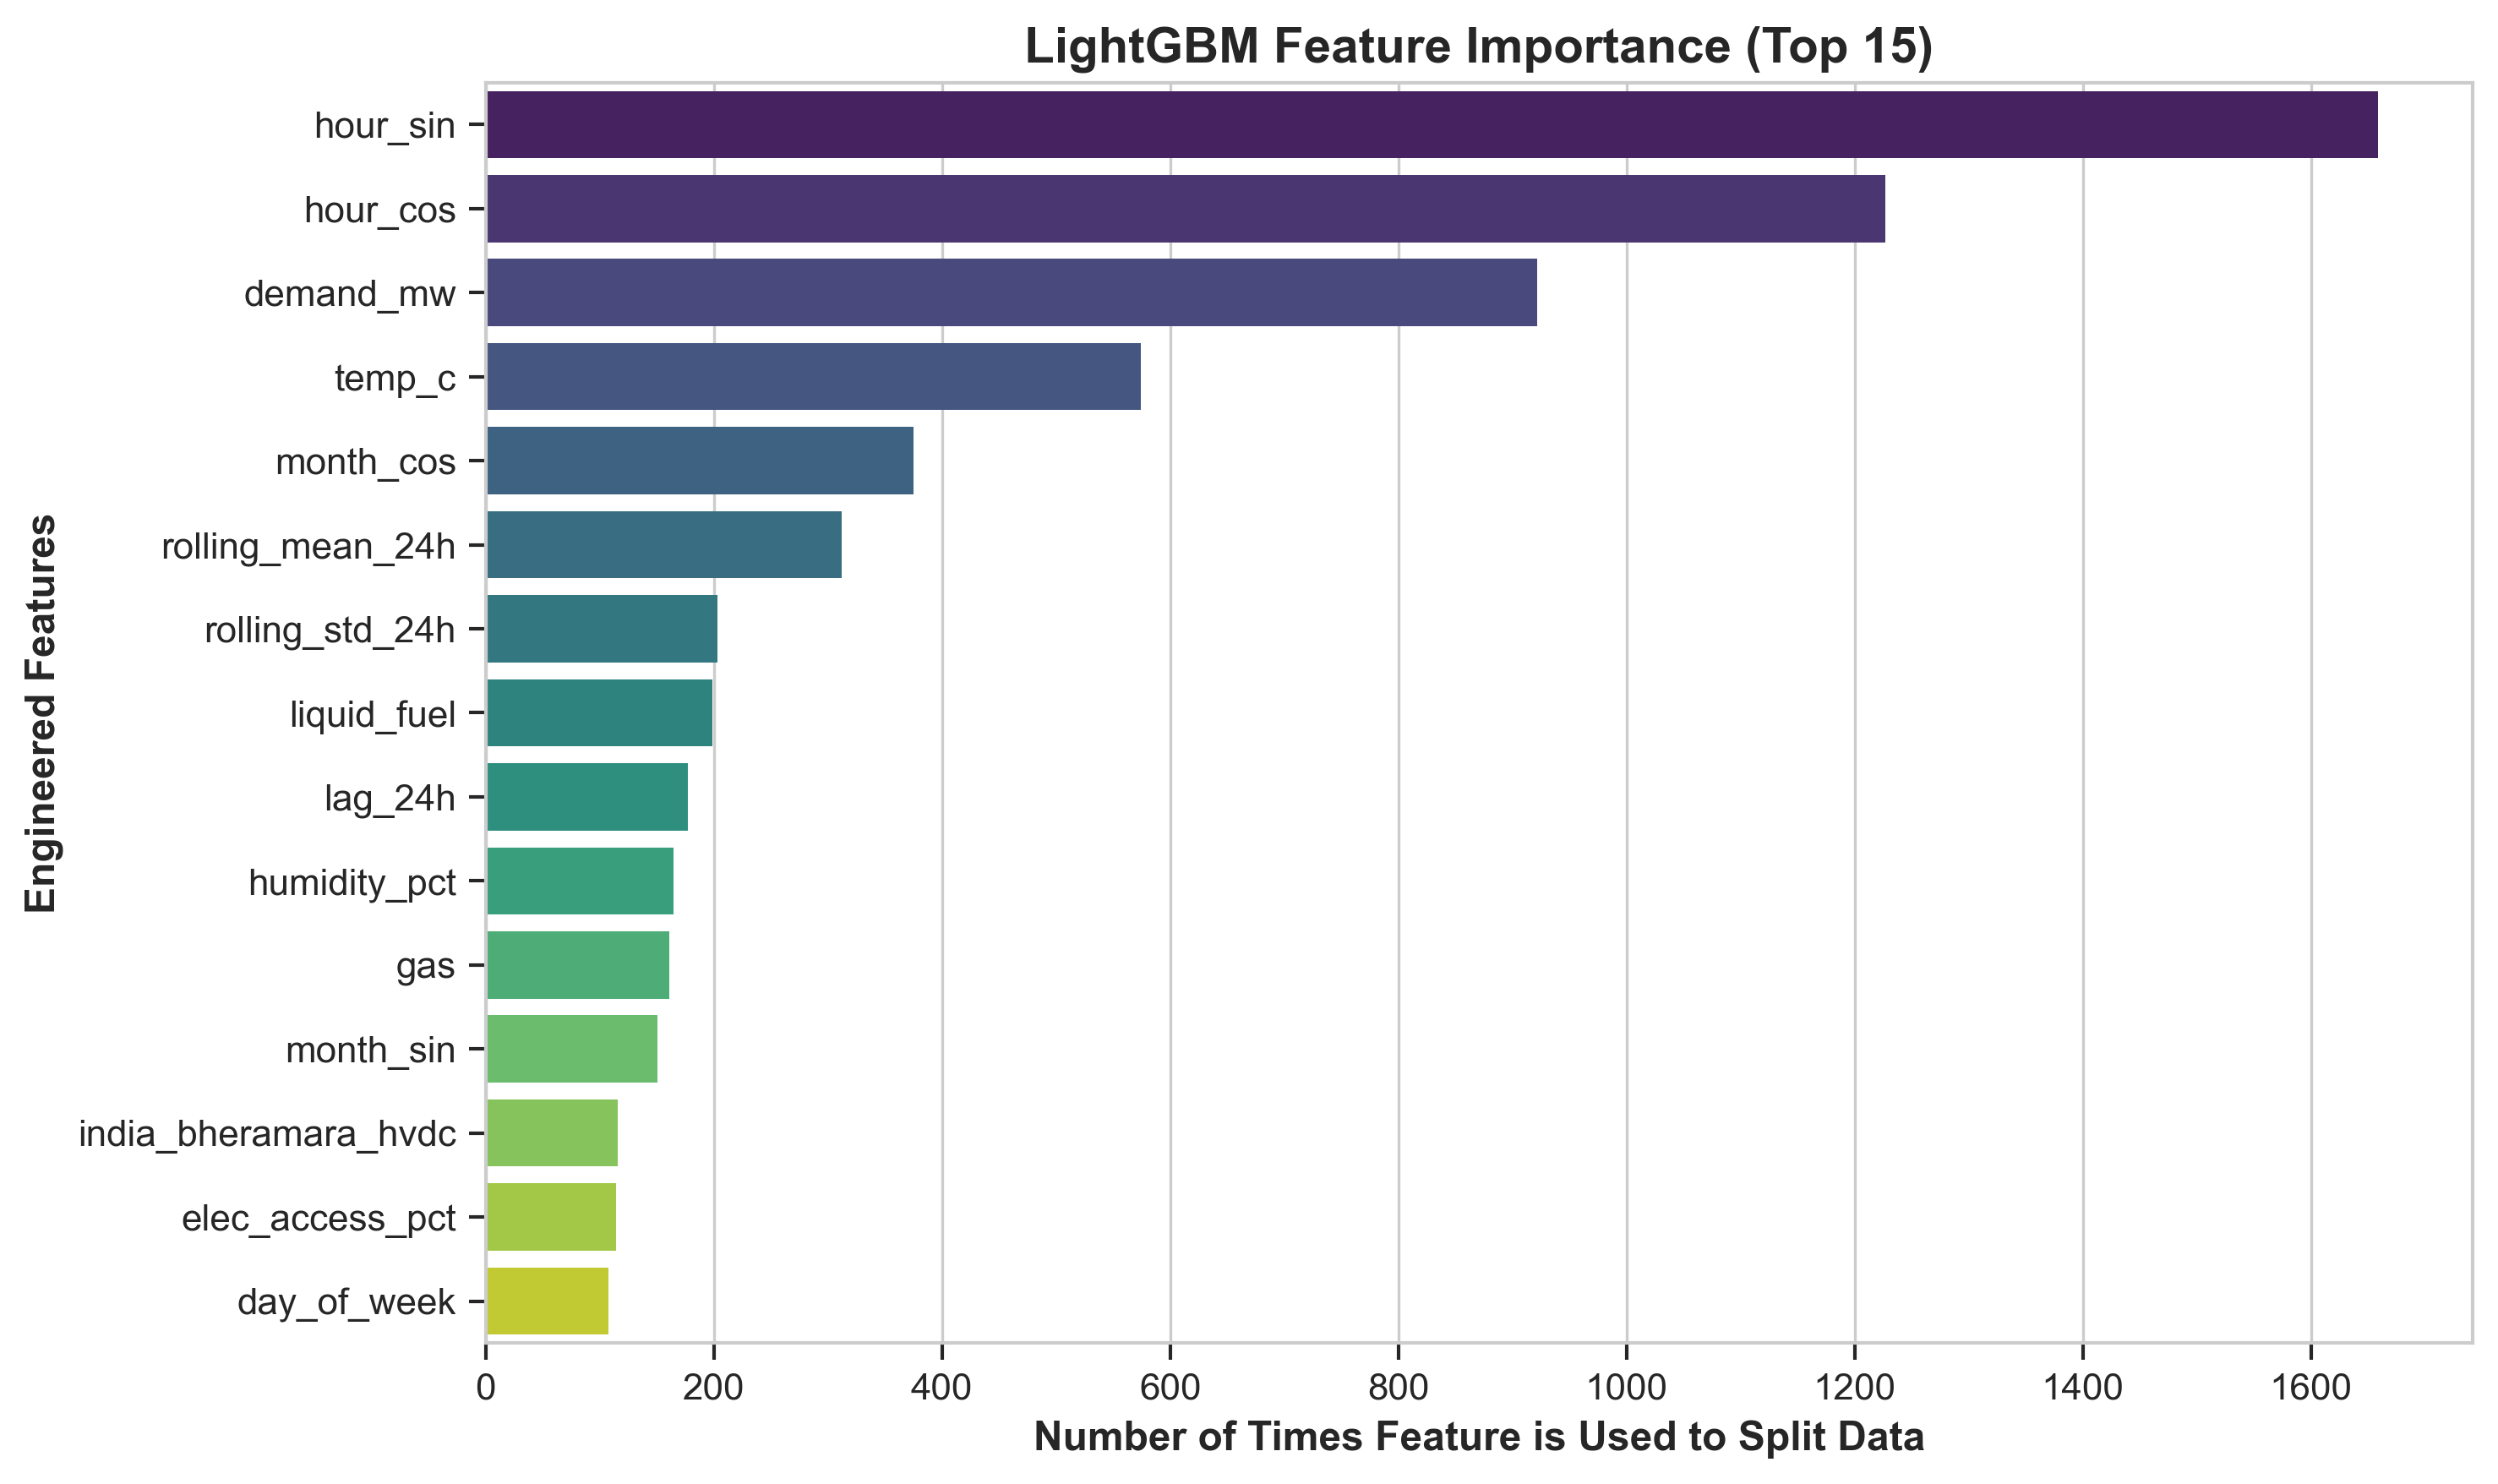

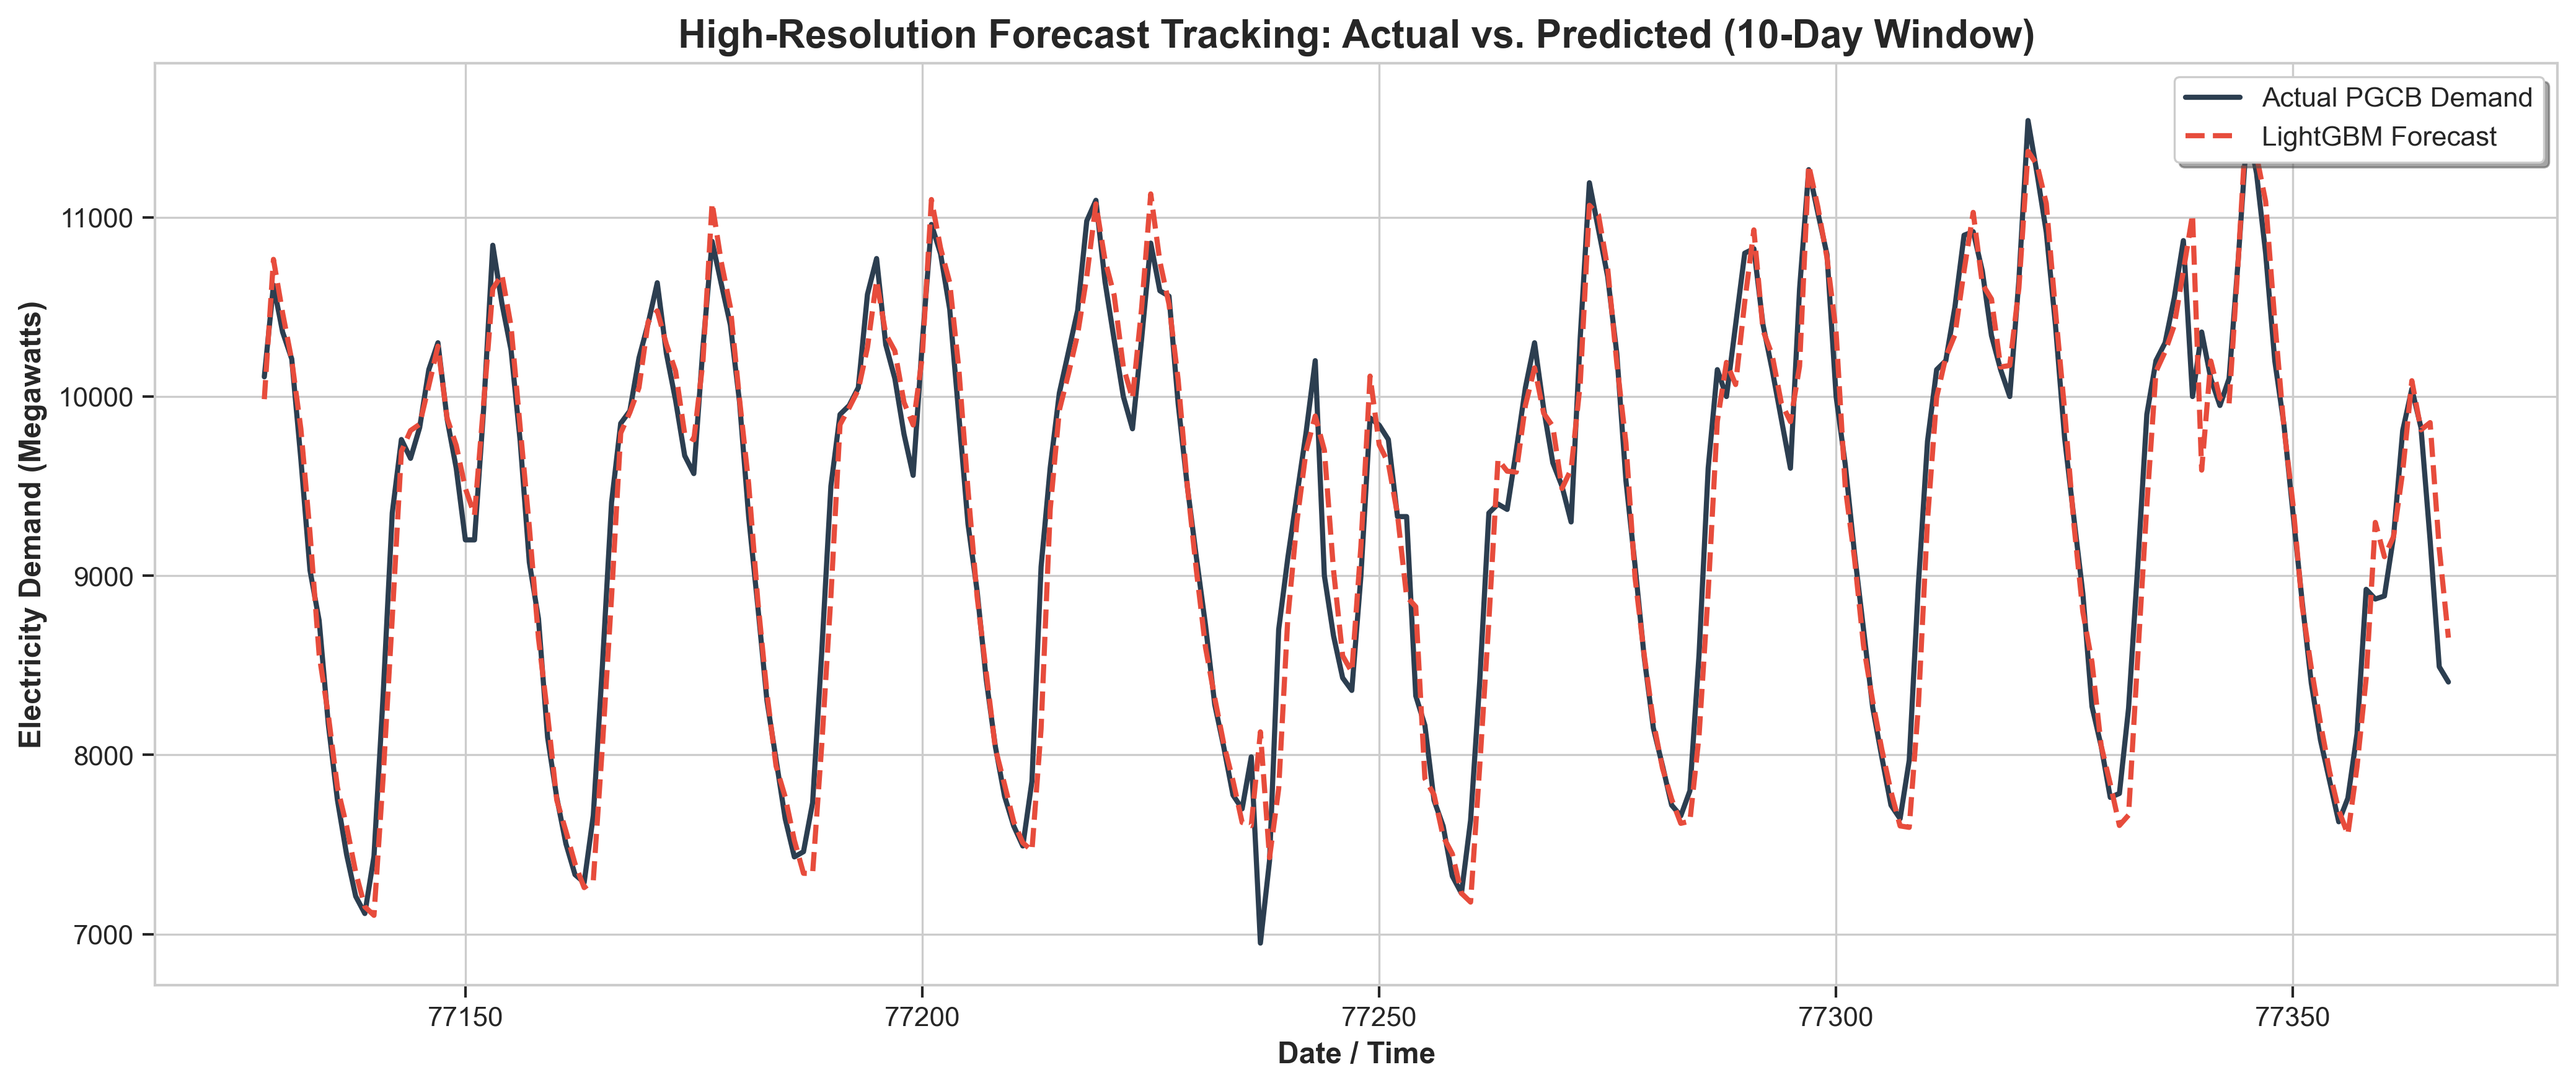

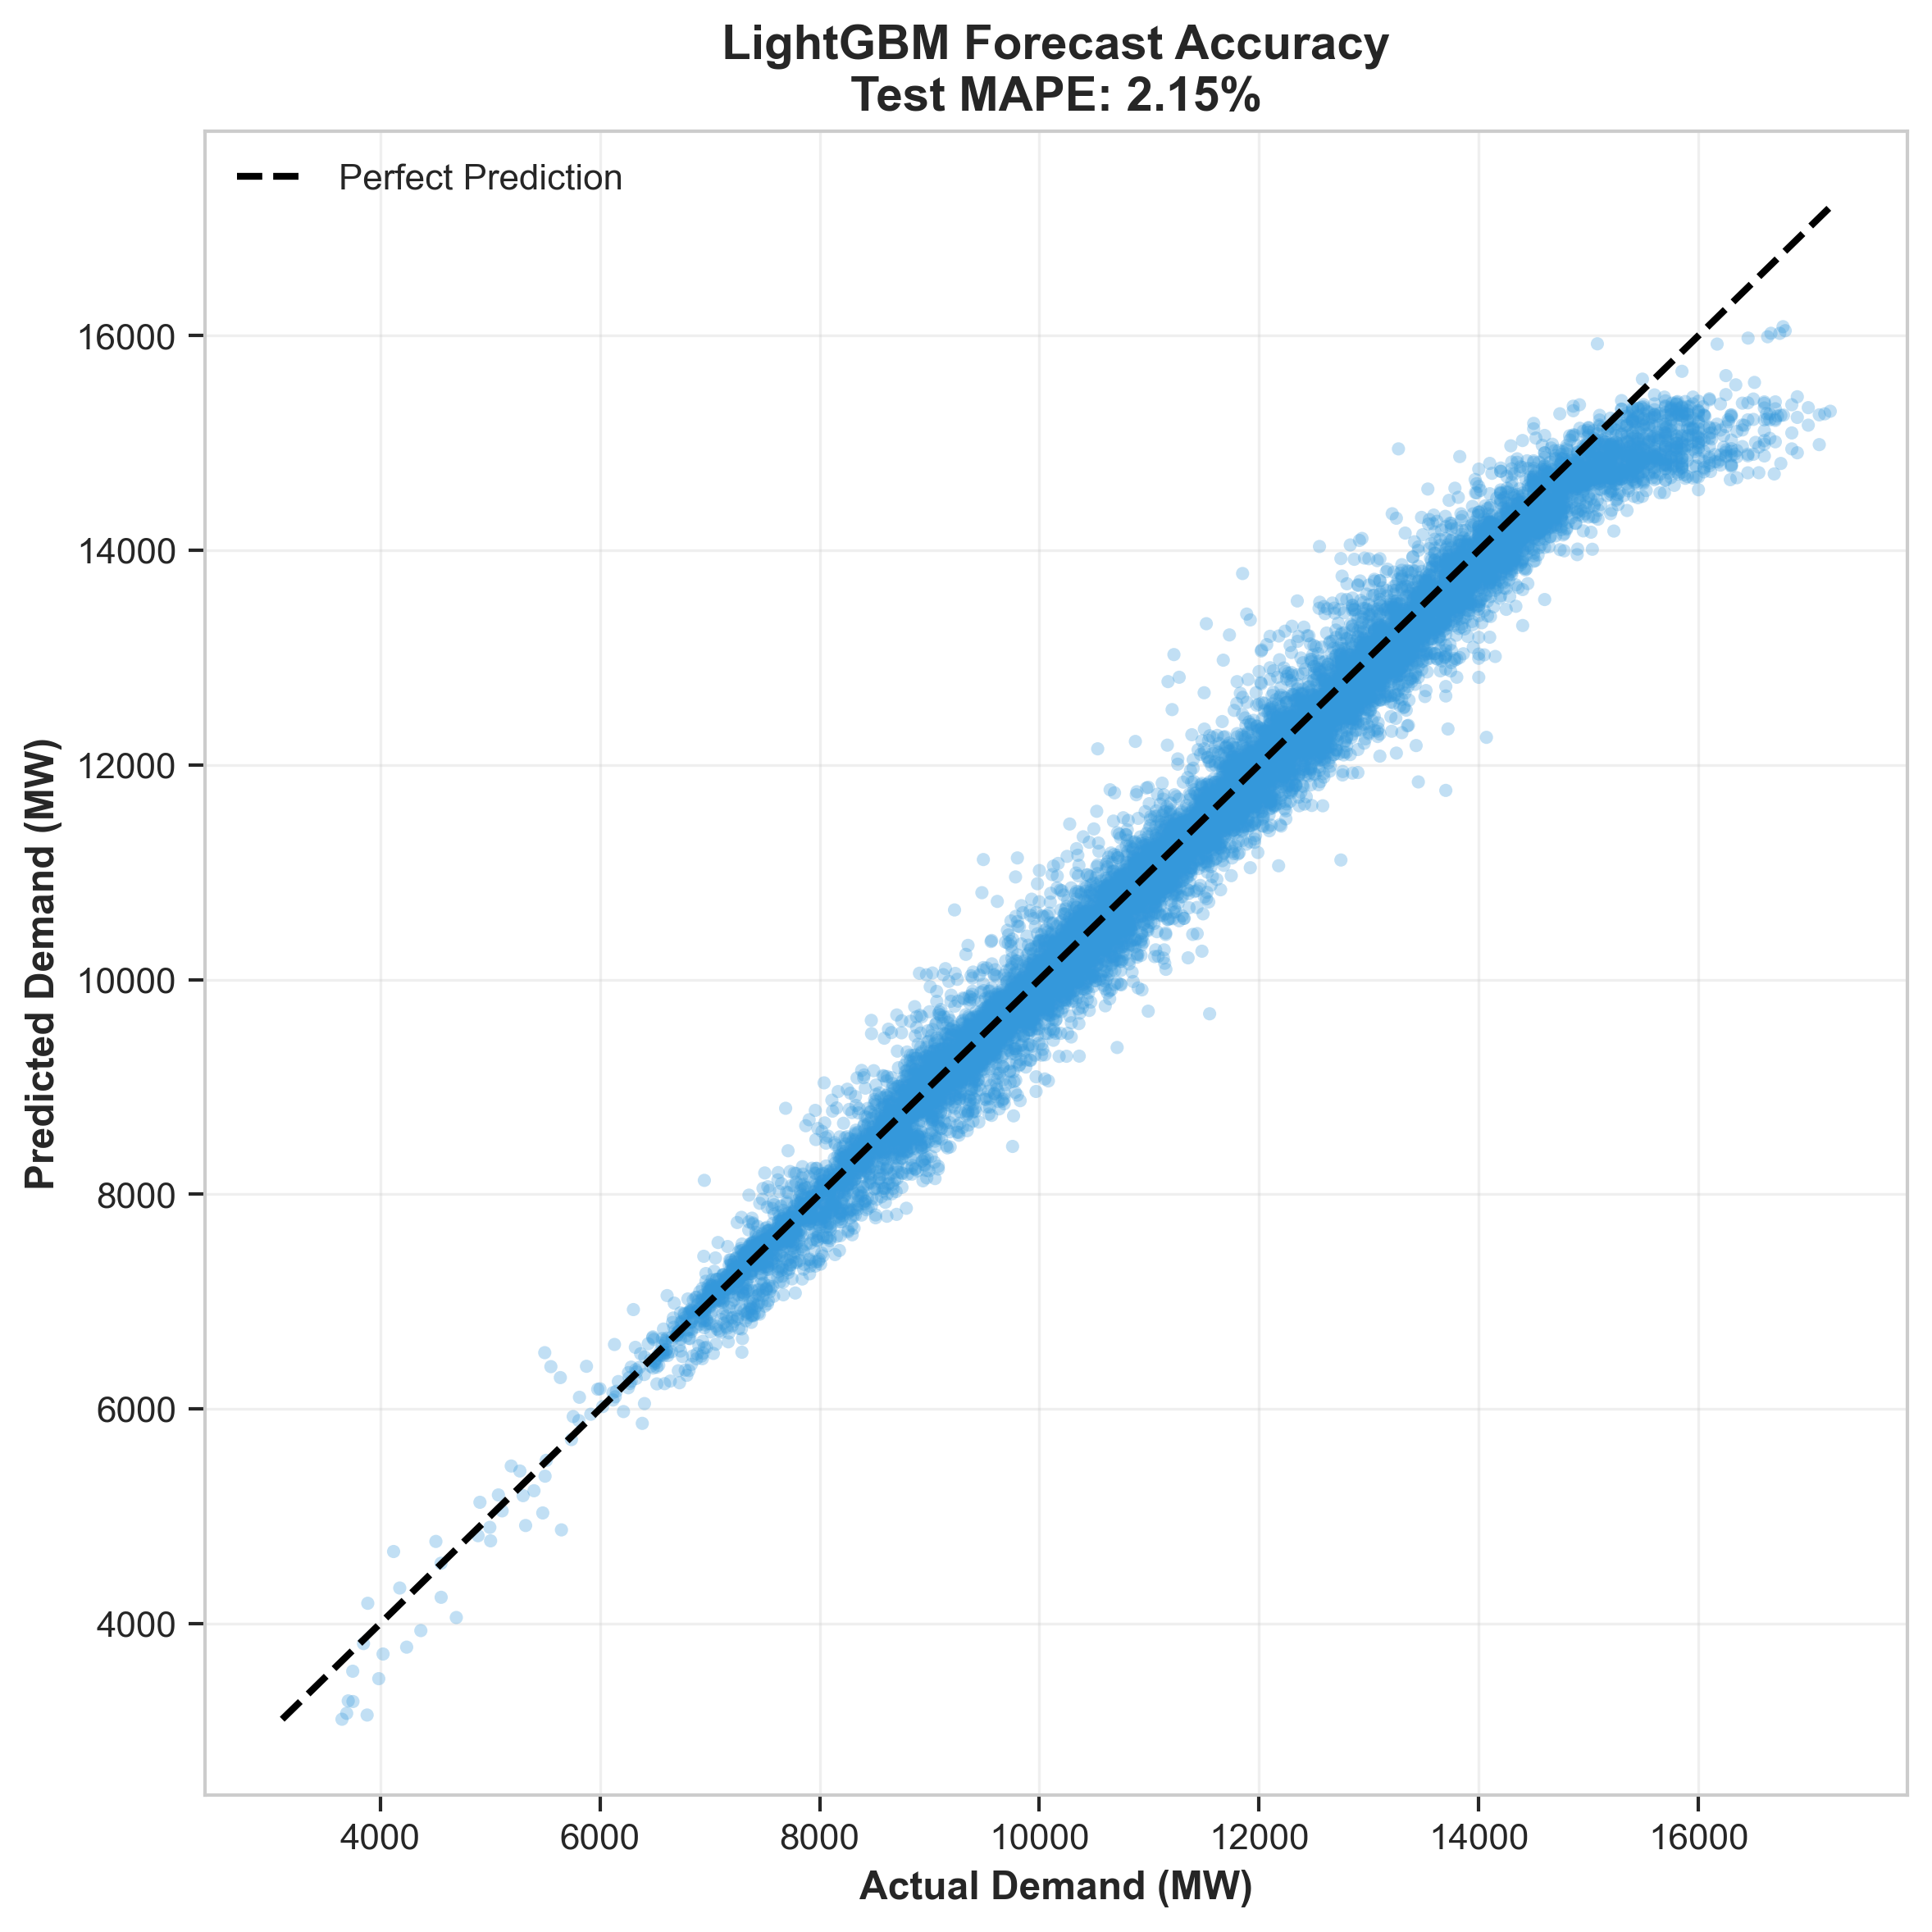

In [ ]:
os.makedirs('visuals', exist_ok=True) # Creates the folder if it doesn't exist
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("paper", font_scale=1.2)

print("Generating all LightGBM production visuals...")


# PLOT 1: Feature Importance
importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_lgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(10, 6), dpi=300)
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('LightGBM Feature Importance (Top 15)', weight='bold', fontsize=14)
plt.xlabel('Number of Times Feature is Used to Split Data', weight='bold')
plt.ylabel('Engineered Features', weight='bold')
plt.tight_layout()
plt.show()
plt.savefig('visuals/feature_importance.png')
plt.close() # Closes the figure to save memory before starting the next one


# PLOT 2: Actual vs. Predicted (10-Day Zoom)
results_df = pd.DataFrame({
    'Actual Demand (MW)': y_test,
    'Predicted Demand (MW)': lgb_pred
}, index=y_test.index)

zoom_window = results_df.iloc[1000:1240] # 10-day slice

plt.figure(figsize=(14, 6), dpi=300)
plt.plot(zoom_window.index, zoom_window['Actual Demand (MW)'], label='Actual PGCB Demand', color='#2c3e50', linewidth=2)
plt.plot(zoom_window.index, zoom_window['Predicted Demand (MW)'], label='LightGBM Forecast', color='#e74c3c', linewidth=2, linestyle='--')
plt.title('High-Resolution Forecast Tracking: Actual vs. Predicted (10-Day Window)', weight='bold', fontsize=15)
plt.xlabel('Date / Time', weight='bold')
plt.ylabel('Electricity Demand (Megawatts)', weight='bold')
plt.legend(loc='upper right', frameon=True, shadow=True)
plt.tight_layout()
plt.show()
plt.savefig('visuals/actual_vs_predicted_zoom.png')
plt.close()


# PLOT 3: 45-Degree Accuracy Scatter
plt.figure(figsize=(8, 8), dpi=300)
plt.scatter(y_test, lgb_pred, alpha=0.3, color='#3498db', edgecolors='none', s=15)

min_val = min(np.min(y_test), np.min(lgb_pred))
max_val = max(np.max(y_test), np.max(lgb_pred))
plt.plot([min_val, max_val], [min_val, max_val], color='black', linewidth=2, linestyle='--', label='Perfect Prediction')

plt.title(f'LightGBM Forecast Accuracy\nTest MAPE: {final_mape:.2f}%', weight='bold', fontsize=14)
plt.xlabel('Actual Demand (MW)', weight='bold')
plt.ylabel('Predicted Demand (MW)', weight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('visuals/accuracy_scatter.png')
plt.show()